## 🚗 Vehicle Damage Detection

This project classifies vehicle images into **7 types of damage** using **EfficientNetB0** with transfer learning and fine-tuning.

In [1]:
%pip install tensorflow 

Note: you may need to restart the kernel to use updated packages.


## Import Libraries

In [2]:
import os
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [3]:
print("TensorFlow version:", tf.__version__)

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    print("\nGPU available:")
    for gpu in gpus:
        print(gpu)
else:
    print("\nNo GPU available.")

TensorFlow version: 2.21.0

No GPU available.


In [4]:
import os

os.chdir(r"e:\Vehicle Damage Assesment")


## Initial Data Exploration

In [5]:
df = pd.read_csv("data/data.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Shape: (1594, 3)

Columns:
['Unnamed: 0', 'image', 'classes']

First 5 rows:


,Unnamed: 0,image,classes
0,0,image/0.jpeg,unknown
1,1,image/1.jpeg,head_lamp
2,2,image/2.jpeg,door_scratch
3,3,image/3.jpeg,head_lamp
4,4,image/4.jpeg,unknown


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1594 entries, 0 to 1593
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  1594 non-null   int64 
 1   image       1594 non-null   object
 2   classes     1594 non-null   object
dtypes: int64(1), object(2)
memory usage: 37.5+ KB


In [7]:
df.isnull().sum()

Unnamed: 0    0
image         0
classes       0
dtype: int64

## Data Cleaning

In [8]:
df = df.drop(columns=["Unnamed: 0"])

## Exploratory Data Analysis (EDA)

In [9]:

print("Number of classes:", df["classes"].nunique())

print("\nClasses:")
print(df["classes"].unique())

print("\nImages per class:")
print(df["classes"].value_counts())

Number of classes: 8

Classes:
['unknown' 'head_lamp' 'door_scratch' 'glass_shatter' 'tail_lamp'
 'bumper_dent' 'door_dent' 'bumper_scratch']

Images per class:
classes
unknown           549
door_dent         192
bumper_scratch    164
door_scratch      154
glass_shatter     137
tail_lamp         136
head_lamp         133
bumper_dent       129
Name: count, dtype: int64


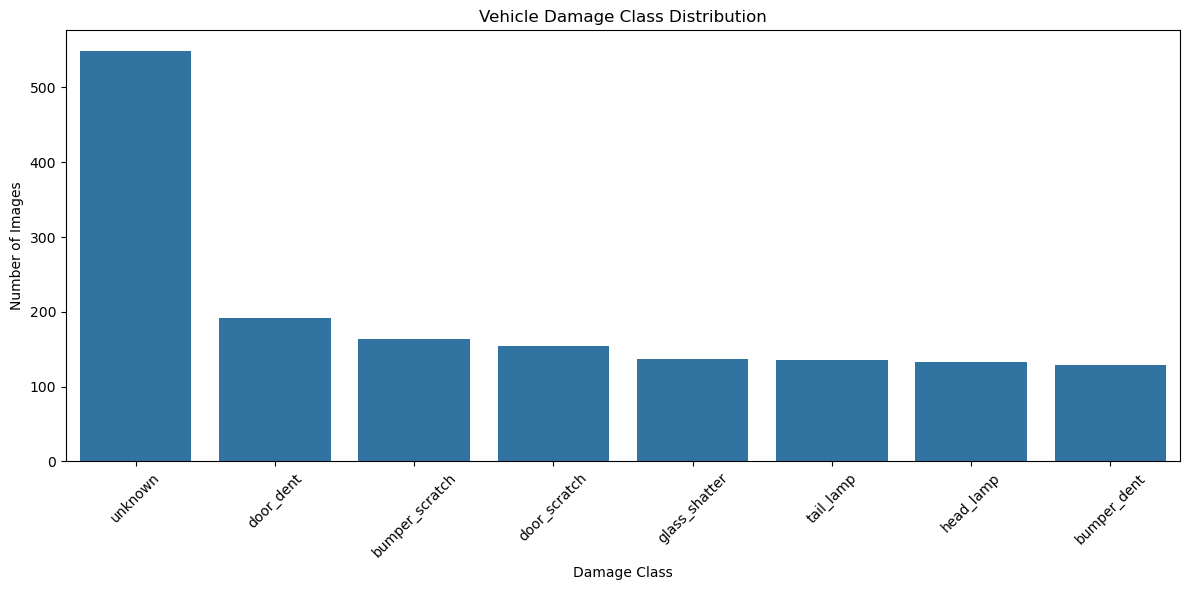

In [10]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x="classes",
    order=df["classes"].value_counts().index
)

plt.xticks(rotation=45)
plt.title("Vehicle Damage Class Distribution")
plt.xlabel("Damage Class")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

## Verifying Image Paths

In [11]:
df["image_path"] = df["image"].apply(
    lambda x: os.path.join("data", x)
)

print(df[["image", "image_path"]].head())

          image         image_path
0  image/0.jpeg  data\image/0.jpeg
1  image/1.jpeg  data\image/1.jpeg
2  image/2.jpeg  data\image/2.jpeg
3  image/3.jpeg  data\image/3.jpeg
4  image/4.jpeg  data\image/4.jpeg


In [12]:
df["exists"] = df["image_path"].apply(os.path.exists)

print("Total records:", len(df))
print("Images found:", df["exists"].sum())
print("Images missing:", (~df["exists"]).sum())

Total records: 1594
Images found: 1594
Images missing: 0


In [13]:
df.head()

,image,classes,image_path,exists
0,image/0.jpeg,unknown,data\image/0.jpeg,True
1,image/1.jpeg,head_lamp,data\image/1.jpeg,True
2,image/2.jpeg,door_scratch,data\image/2.jpeg,True
3,image/3.jpeg,head_lamp,data\image/3.jpeg,True
4,image/4.jpeg,unknown,data\image/4.jpeg,True


In [14]:
df.drop(columns=["exists"], inplace=True)

## Visual Inspection of Sample Images

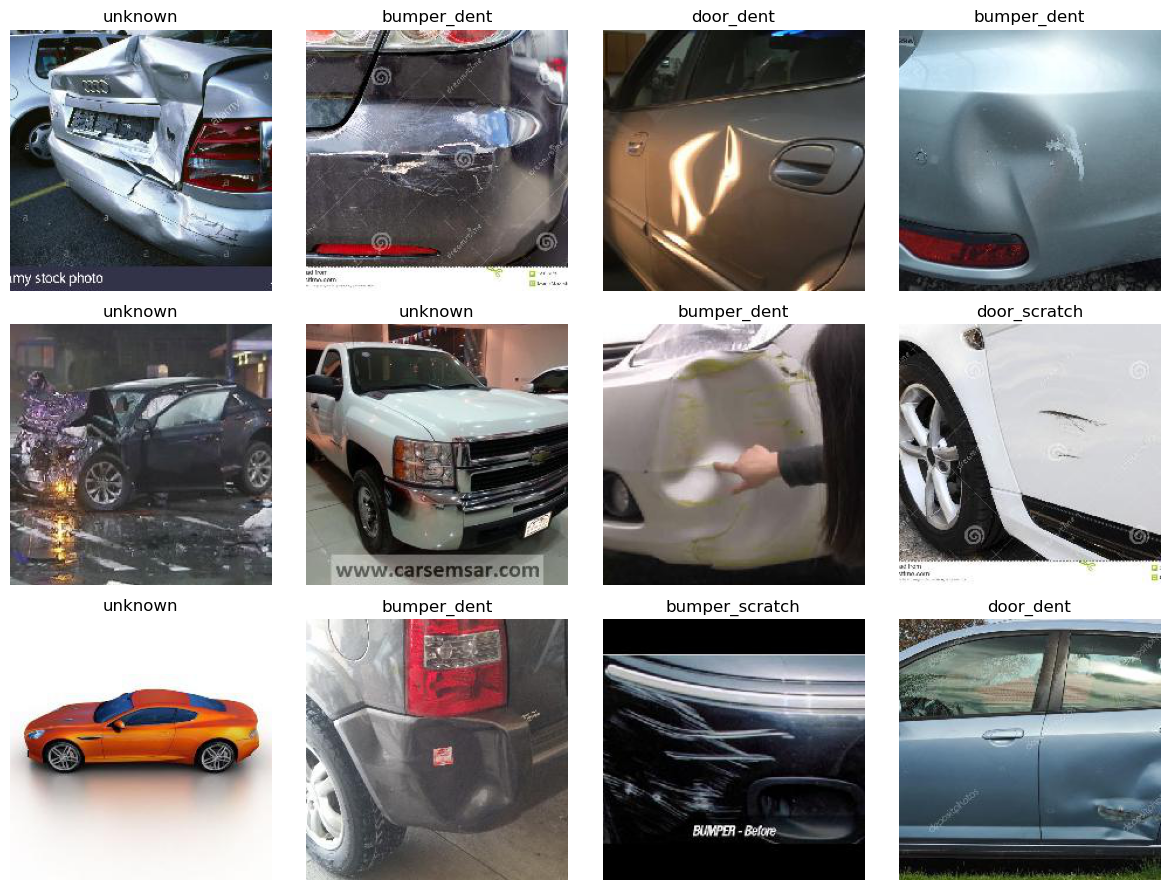

In [15]:
plt.figure(figsize=(12, 9))

sample_df = df.sample(
    12,
    random_state=42
)

for i, (_, row) in enumerate(sample_df.iterrows()):

    img = Image.open(row["image_path"])

    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(row["classes"])
    plt.axis("off")

plt.tight_layout()
plt.show()

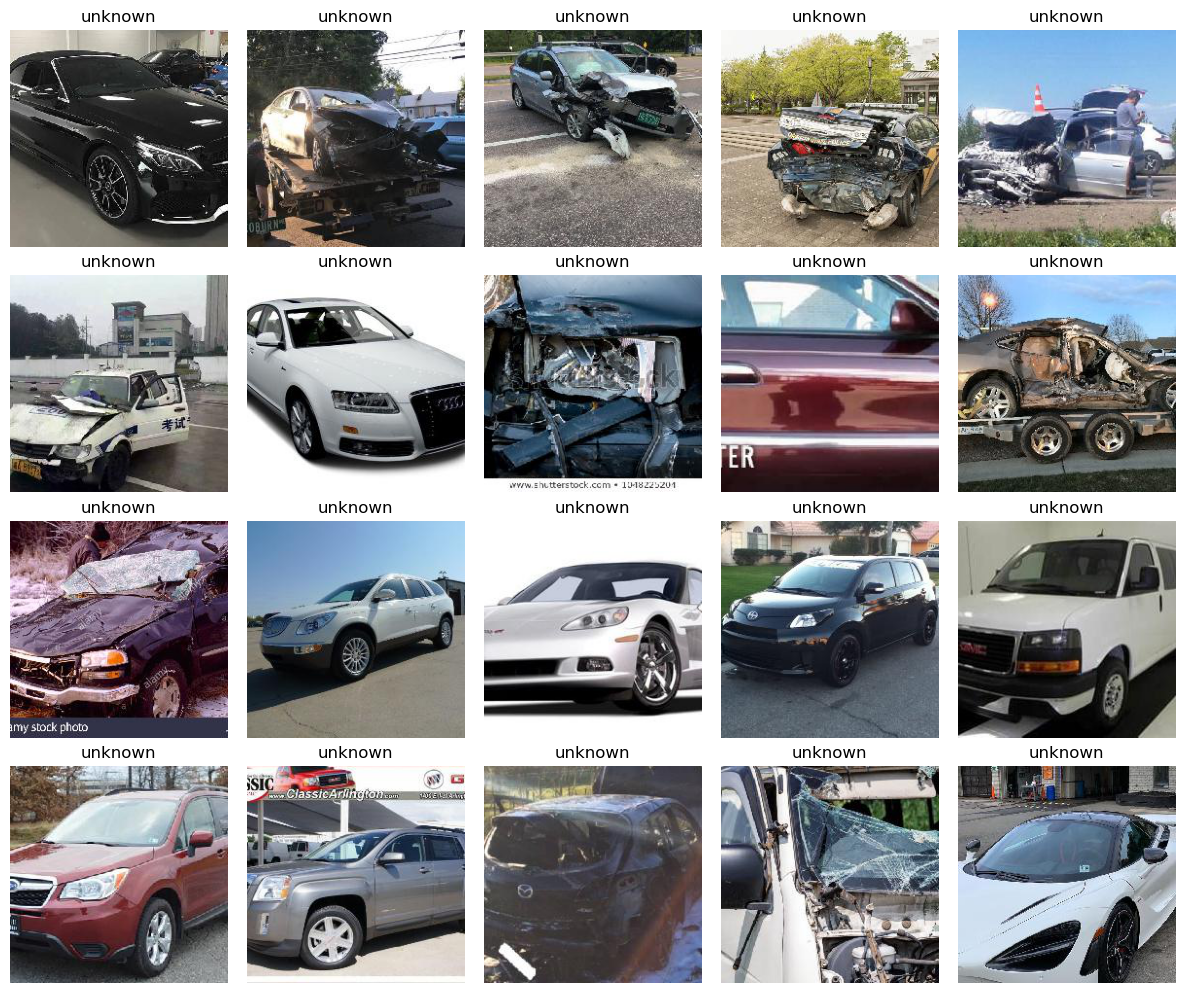

In [16]:
unknown_df = df[
    df["classes"] == "unknown"
]

sample_unknown = unknown_df.sample(
    20,
    random_state=42
)

plt.figure(figsize=(12, 10))

for i, (_, row) in enumerate(
    sample_unknown.iterrows()
):

    image = Image.open(
        row["image_path"]
    )

    plt.subplot(4, 5, i + 1)
    plt.imshow(image)
    plt.title("unknown")
    plt.axis("off")

plt.tight_layout()
plt.show()


After visually inspecting the `unknown` class, we found that it contains
heterogeneous images such as normal vehicles, severely damaged vehicles,
and damage that does not correspond to a single defined category.

Treating all of these images as one class would introduce label noise.

Therefore, the primary multiclass classification model will use only the
seven well-defined vehicle-damage categories.



## Building the Damage Classification Dataset

Dropping the noisy `unknown` class and keeping only the 7 well-defined damage categories for the classifier.

In [17]:
damage_classes = [
    "head_lamp",
    "door_scratch",
    "glass_shatter",
    "tail_lamp",
    "bumper_dent",
    "door_dent",
    "bumper_scratch"
]

damage_df = df[
    df["classes"].isin(damage_classes)
].copy()

print("Original dataset size:", len(df))
print("Damage classification dataset size:", len(damage_df))

Original dataset size: 1594
Damage classification dataset size: 1045


In [18]:
import hashlib

def image_hash(path):
    with open(path, "rb") as file:
        return hashlib.sha256(file.read()).hexdigest()

damage_df["image_hash"] = damage_df["image_path"].apply(
    image_hash
)

duplicate_count = damage_df.duplicated(
    subset="image_hash",
    keep=False
).sum()

print("Duplicate image records found:", duplicate_count)

damage_df = damage_df.drop_duplicates(
    subset="image_hash",
    keep="first"
).copy()

print("Unique damage images:", len(damage_df))

Duplicate image records found: 172
Unique damage images: 959


In [19]:
damage_counts = damage_df["classes"].value_counts()

print(damage_counts)

classes
door_dent         192
door_scratch      154
glass_shatter     136
tail_lamp         135
head_lamp         132
bumper_dent       128
bumper_scratch     82
Name: count, dtype: int64


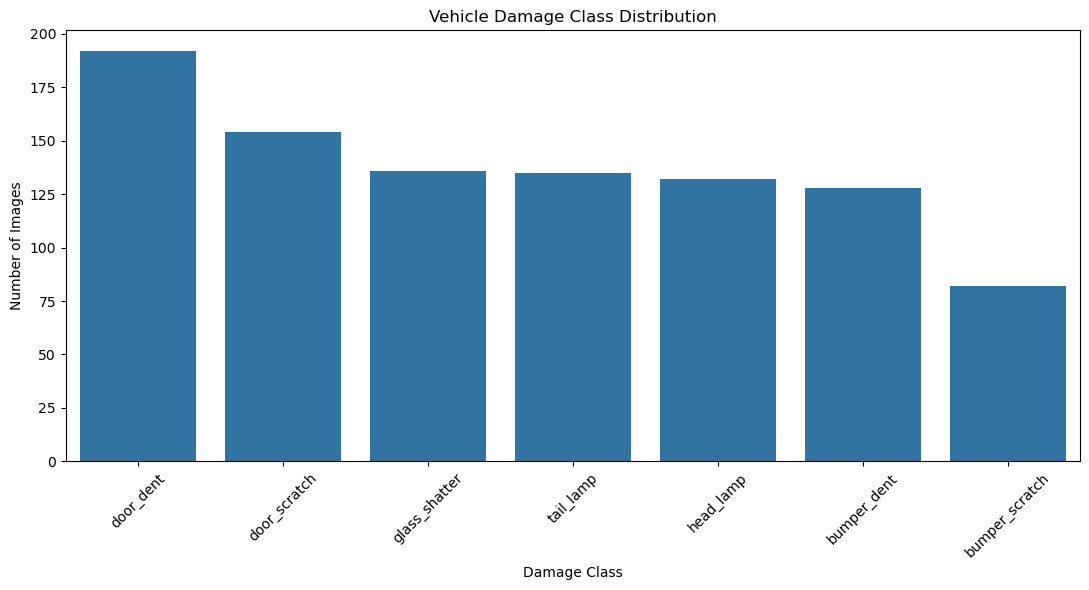

In [20]:
plt.figure(figsize=(11, 6))

sns.barplot(
    x=damage_counts.index,
    y=damage_counts.values
)

plt.title("Vehicle Damage Class Distribution")
plt.xlabel("Damage Class")
plt.ylabel("Number of Images")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Label Encoding

In [21]:
label_encoder = LabelEncoder()

damage_df["label"] = label_encoder.fit_transform(
    damage_df["classes"]
)


In [22]:
class_mapping = {
    i: class_name
    for i, class_name in enumerate(
        label_encoder.classes_
    )
}

print(class_mapping)

{0: 'bumper_dent', 1: 'bumper_scratch', 2: 'door_dent', 3: 'door_scratch', 4: 'glass_shatter', 5: 'head_lamp', 6: 'tail_lamp'}


In [23]:
NUM_CLASSES = len(label_encoder.classes_)

print("Number of classes:", NUM_CLASSES)

Number of classes: 7


## Train, Validation and Test Split

In [24]:
train_df, temp_df = train_test_split(
    damage_df,
    test_size=0.30,
    stratify=damage_df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

In [25]:
print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Test images:", len(test_df))

Training images: 671
Validation images: 144
Test images: 144


In [26]:
print("TRAINING")
print(train_df["classes"].value_counts())

print("\nVALIDATION")
print(val_df["classes"].value_counts())

print("\nTEST")
print(test_df["classes"].value_counts())

TRAINING
classes
door_dent         134
door_scratch      108
glass_shatter      95
tail_lamp          95
head_lamp          92
bumper_dent        90
bumper_scratch     57
Name: count, dtype: int64

VALIDATION
classes
door_dent         29
door_scratch      23
glass_shatter     21
head_lamp         20
tail_lamp         20
bumper_dent       19
bumper_scratch    12
Name: count, dtype: int64

TEST
classes
door_dent         29
door_scratch      23
tail_lamp         20
head_lamp         20
glass_shatter     20
bumper_dent       19
bumper_scratch    13
Name: count, dtype: int64


## Handling Class Imbalance

Computing balanced class weights so the model doesn't just learn to favor the larger classes.

In [27]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(
    train_df["label"]
)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(
    zip(classes, weights)
)

In [28]:
for class_id, weight in class_weights.items():

    class_name = label_encoder.inverse_transform(
        [class_id]
    )[0]

    print(
        f"{class_name:20s} → {weight:.3f}"
    )

bumper_dent          → 1.065
bumper_scratch       → 1.682
door_dent            → 0.715
door_scratch         → 0.888
glass_shatter        → 1.009
head_lamp            → 1.042
tail_lamp            → 1.009


## Image Data Pipeline

Creating an image data pipeline that loads, resizes, and batches images for training, validation, and testing.

In [29]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

def load_image(path, label):

    image = tf.io.read_file(path)

    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    image = tf.image.resize_with_pad(
    image,
    IMG_SIZE[0],
    IMG_SIZE[1]
)

    image = tf.cast(
        image,
        tf.float32
    )

    return image, label

In [30]:
def create_dataset(
    dataframe,
    shuffle=False
):

    paths = dataframe[
        "image_path"
    ].values

    labels = dataframe[
        "label"
    ].values

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    dataset = dataset.map(
        load_image,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        tf.data.AUTOTUNE
    )

    return dataset

In [31]:
train_ds = create_dataset(
    train_df,
    shuffle=True
)

val_ds = create_dataset(
    val_df,
    shuffle=False
)

test_ds = create_dataset(
    test_df,
    shuffle=False
)

In [32]:
images, labels = next(
    iter(train_ds)
)

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

Image batch shape: (16, 224, 224, 3)
Label batch shape: (16,)


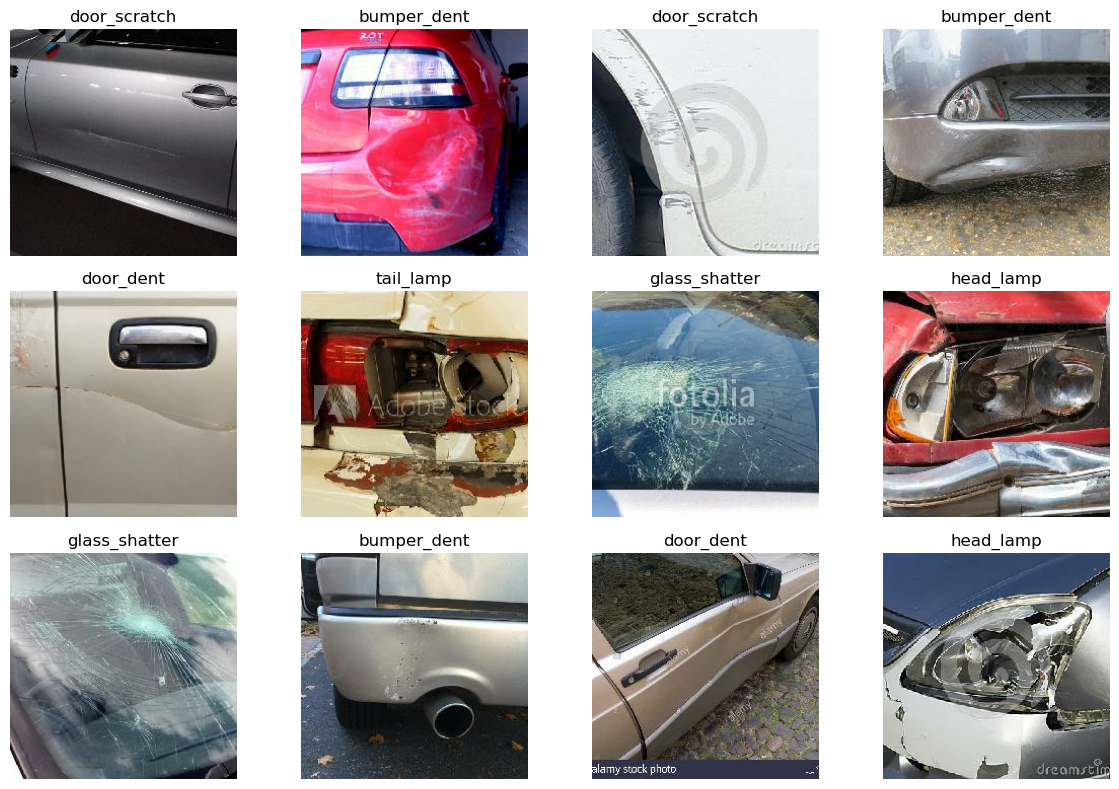

In [33]:
plt.figure(figsize=(12, 8))

for i in range(min(12, len(images))):

    plt.subplot(3, 4, i + 1)

    plt.imshow(
        images[i].numpy().astype("uint8")
    )

    class_name = label_encoder.inverse_transform(
        [labels[i].numpy()]
    )[0]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

## Data Augmentation

In [34]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip(
            "horizontal",
            seed=SEED
        ),
        layers.RandomRotation(
            0.08,
            seed=SEED + 1
        ),
        layers.RandomZoom(
            0.10,
            seed=SEED + 2
        ),
        layers.RandomContrast(
            0.10,
            seed=SEED + 3
        ),
        layers.RandomTranslation(
            height_factor=0.08,
            width_factor=0.08,
            seed=SEED + 4
        )
    ],
    name="data_augmentation"
)

## Transfer Learning with EfficientNetB0

Using a pretrained EfficientNetB0 as a frozen feature extractor, with a custom classification head on top.

In [35]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

print("EfficientNetB0 loaded.")

EfficientNetB0 loaded.


In [36]:
base_model.trainable = False

In [37]:
# Input
inputs = keras.Input(shape=(224, 224, 3))

# Augmentation
x = data_augmentation(inputs)

# EfficientNetB0 feature extraction
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)

# Classification
outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax"
)(x)

model = keras.Model(
    inputs=inputs,
    outputs=outputs
)


In [38]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │         8,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,058,538 (15.48 MB)

 Trainable params: 8,967 (35.03 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

### Stage 1 — Transfer Learning & Model Training

Training only the new classification head while the EfficientNetB0 backbone stays frozen.
This allows the new classifier to learn the relationship between the pretrained visual features and the seven vehicle damage categories without significantly changing the pretrained feature extractor.

In [39]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [40]:
os.makedirs(
    "models",
    exist_ok=True
)

In [41]:
callbacks = [

    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.2,
        patience=2,
        min_lr=1e-7
    ),

    keras.callbacks.ModelCheckpoint(
        "models/best_vehicle_damage_model.keras",
        monitor="val_accuracy",
        save_best_only=True
    )
]

In [42]:
EPOCHS = 8

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/8


c:\Users\Dell\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 327ms/step - accuracy: 0.2757 - loss: 1.8303 - val_accuracy: 0.6250 - val_loss: 1.3414 - learning_rate: 0.0010
Epoch 2/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 11s 256ms/step - accuracy: 0.5946 - loss: 1.2448 - val_accuracy: 0.7014 - val_loss: 1.0331 - learning_rate: 0.0010
Epoch 3/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 233ms/step - accuracy: 0.6841 - loss: 1.0297 - val_accuracy: 0.7083 - val_loss: 0.9367 - learning_rate: 0.0010
Epoch 4/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 219ms/step - accuracy: 0.7526 - loss: 0.8857 - val_accuracy: 0.7639 - val_loss: 0.8374 - learning_rate: 0.0010
Epoch 5/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.7720 - loss: 0.7734 - val_accuracy: 0.7292 - val_loss: 0.8137 - learning_rate: 0.0010
Epoch 6/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 9s 212ms/step - accuracy: 0.7630 - loss: 0.7236 - val_accuracy: 0.7500 - val_loss: 0.7785 - learning_rate: 0.0010
Epoch 7/8
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 247ms/step - accuracy: 0.7914 - loss: 0.6680 - val_accuracy:

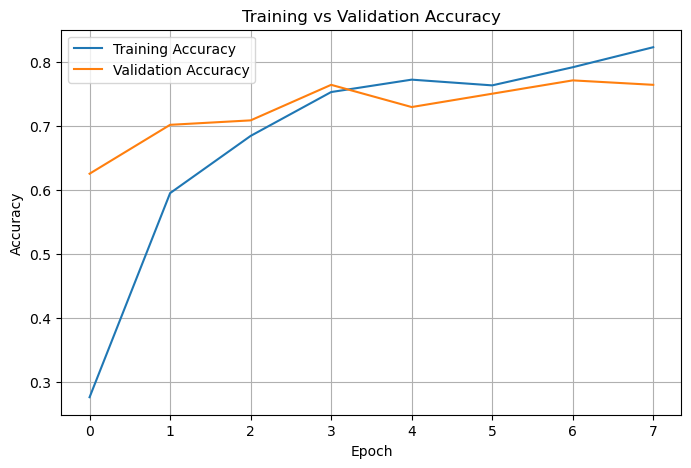

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"],label="Training Accuracy")

plt.plot(history.history["val_accuracy"],label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

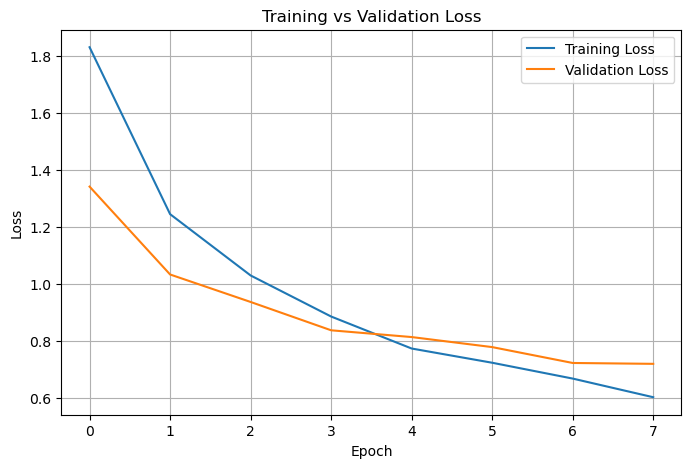

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"],label="Training Loss")

plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

### Stage 2  —  Fine-Tuning the Model

Unfreezing the top layers of the backbone and continuing training at a much lower learning rate to adapt the pretrained features to vehicle damage images.

In [45]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable layers:")
for layer in base_model.layers:
    if layer.trainable:
        print(layer.name)

Trainable layers:
block6d_expand_bn
block6d_expand_activation
block6d_dwconv
block6d_bn
block6d_activation
block6d_se_squeeze
block6d_se_reshape
block6d_se_reduce
block6d_se_expand
block6d_se_excite
block6d_project_conv
block6d_project_bn
block6d_drop
block6d_add
block7a_expand_conv
block7a_expand_bn
block7a_expand_activation
block7a_dwconv
block7a_bn
block7a_activation
block7a_se_squeeze
block7a_se_reshape
block7a_se_reduce
block7a_se_expand
block7a_se_excite
block7a_project_conv
block7a_project_bn
top_conv
top_bn
top_activation


In [46]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5), loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [47]:
FINE_TUNE_EPOCHS = 6

initial_epoch = len(history.history["loss"])

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epoch + FINE_TUNE_EPOCHS,
    initial_epoch=initial_epoch,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 9/14
42/42 ━━━━━━━━━━━━━━━━━━━━ 20s 280ms/step - accuracy: 0.6513 - loss: 1.0328 - val_accuracy: 0.7708 - val_loss: 0.7088 - learning_rate: 1.0000e-05
Epoch 10/14
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 241ms/step - accuracy: 0.6945 - loss: 0.9796 - val_accuracy: 0.7500 - val_loss: 0.7191 - learning_rate: 1.0000e-05
Epoch 11/14
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.6990 - loss: 0.9387 - val_accuracy: 0.7431 - val_loss: 0.7365 - learning_rate: 1.0000e-05
Epoch 12/14
42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 240ms/step - accuracy: 0.7198 - loss: 0.8870 - val_accuracy: 0.7153 - val_loss: 0.7658 - learning_rate: 2.0000e-06


### Model Evaluation

Reloading the best checkpoint (by validation accuracy) and evaluating it on the held-out test set.

In [48]:
model = keras.models.load_model(
    "models/best_vehicle_damage_model.keras"
)

In [49]:
test_loss, test_accuracy = model.evaluate(test_ds,verbose=1)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.7500 - loss: 0.6609
Test Loss: 0.6609
Test Accuracy: 0.7500


In [50]:
y_true = []
y_pred = []
y_prob = []

for images, labels in test_ds:

    predictions = model.predict(images,verbose=0)

    predicted_labels = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)
    y_prob.extend(predictions)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)
print("Prediction probabilities shape:", y_prob.shape)

True labels shape: (144,)
Predicted labels shape: (144,)
Prediction probabilities shape: (144, 7)


In [ ]:
accuracy = accuracy_score(y_true,y_pred)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.7500


In [52]:
#Macro F1-Score
macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print(f"Macro F1-score: {macro_f1:.4f}")

Macro F1-score: 0.7473


In [53]:
print(classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_
    ))

                precision    recall  f1-score   support

   bumper_dent       0.85      0.58      0.69        19
bumper_scratch       0.48      0.77      0.59        13
     door_dent       0.77      0.69      0.73        29
  door_scratch       0.70      0.83      0.76        23
 glass_shatter       0.89      0.85      0.87        20
     head_lamp       0.71      0.75      0.73        20
     tail_lamp       0.94      0.80      0.86        20

      accuracy                           0.75       144
     macro avg       0.76      0.75      0.75       144
  weighted avg       0.78      0.75      0.75       144



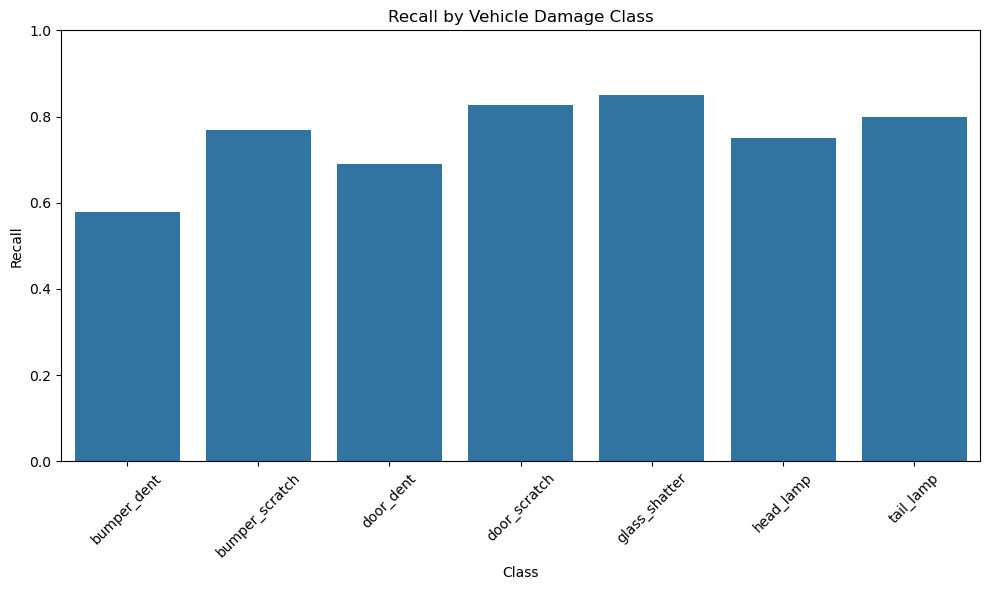

In [54]:
from sklearn.metrics import recall_score

recalls = recall_score(
    y_true,
    y_pred,
    average=None
)

recall_df = pd.DataFrame({
    "Class": label_encoder.classes_,
    "Recall": recalls
})

plt.figure(figsize=(10, 6))

sns.barplot(
    data=recall_df,
    x="Class",
    y="Recall"
)

plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.title("Recall by Vehicle Damage Class")
plt.tight_layout()
plt.show()

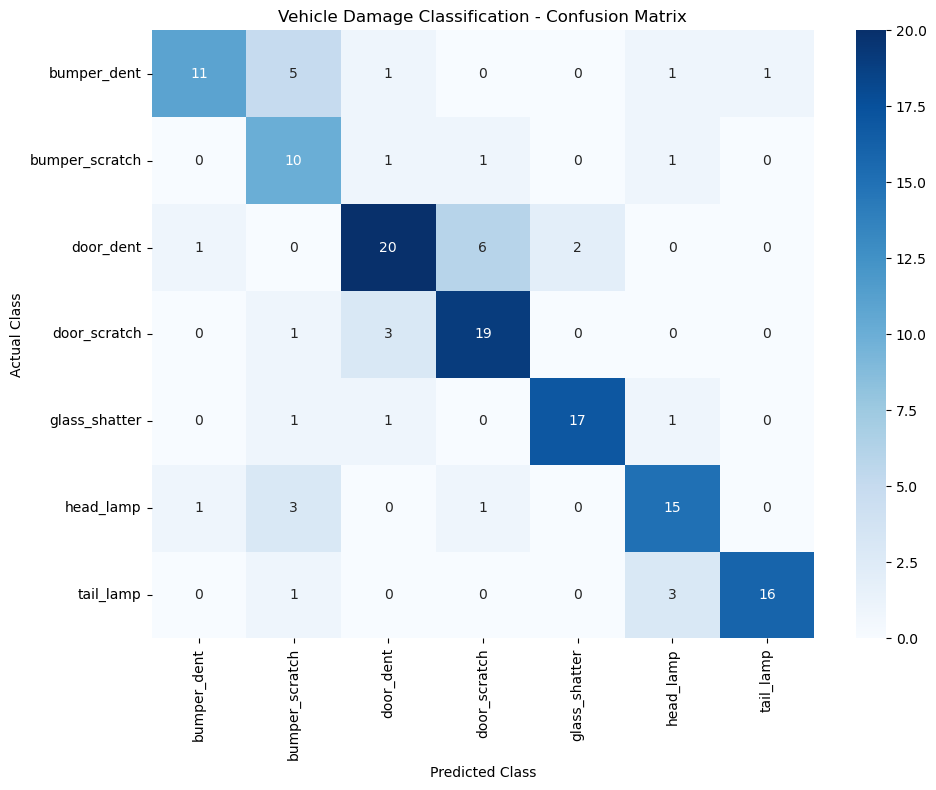

In [55]:
#Confusion Matrix
cm = confusion_matrix(y_true,y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Vehicle Damage Classification - Confusion Matrix"
)

plt.tight_layout()
plt.show()

The confusion matrix shows strong performance for glass-shatter and tail-lamp damage. The main errors occur between visually similar classes on the same part — bumper dent vs. bumper scratch, and door dent vs. door scratch.

## Detailed Performance Metrics

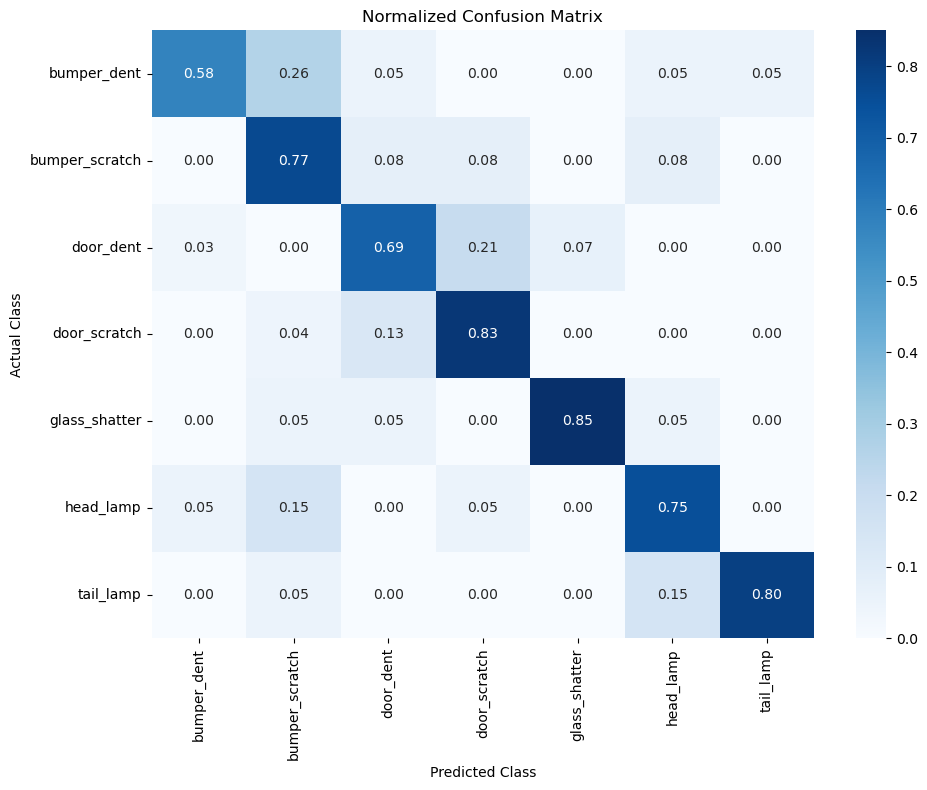

In [56]:
cm_normalized = (
    cm.astype("float")
    / cm.sum(axis=1)[:, np.newaxis]
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.title(
    "Normalized Confusion Matrix"
)

plt.tight_layout()
plt.show()

In [57]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

metrics_df = pd.DataFrame(
    report_dict
).transpose()

metrics_df

,precision,recall,f1-score,support
bumper_dent,0.846154,0.578947,0.687500,19.00
bumper_scratch,0.476190,0.769231,0.588235,13.00
door_dent,0.769231,0.689655,0.727273,29.00
door_scratch,0.703704,0.826087,0.760000,23.00
glass_shatter,0.894737,0.850000,0.871795,20.00
head_lamp,0.714286,0.750000,0.731707,20.00
tail_lamp,0.941176,0.800000,0.864865,20.00
accuracy,0.750000,0.750000,0.750000,0.75
macro avg,0.763640,0.751989,0.747339,144.00
weighted avg,0.776141,0.750000,0.754499,144.00


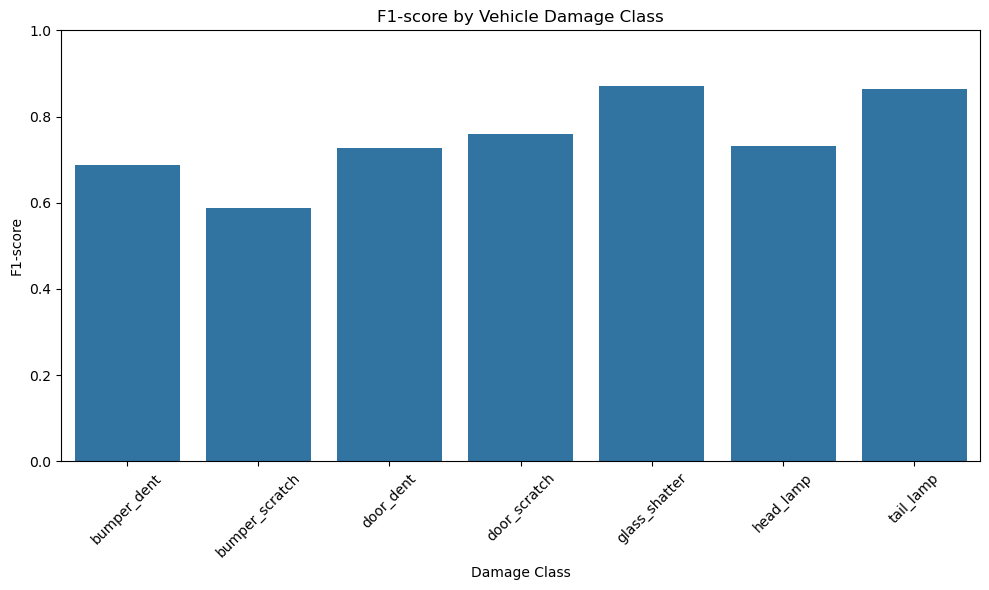

In [58]:
class_names = label_encoder.classes_

class_f1 = [
    report_dict[class_name]["f1-score"]
    for class_name in class_names
]

plt.figure(figsize=(10, 6))

sns.barplot(
    x=class_names,
    y=class_f1
)

plt.ylim(0, 1)

plt.xlabel("Damage Class")
plt.ylabel("F1-score")

plt.title(
    "F1-score by Vehicle Damage Class"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Error Analysis

Looking at individual misclassified images and low-confidence predictions rather than just the aggregate metrics.

In [59]:
test_results = test_df.copy()

test_results["true_label"] = [
    label_encoder.inverse_transform([x])[0]
    for x in y_true
]

test_results["predicted_label"] = [
    label_encoder.inverse_transform([x])[0]
    for x in y_pred
]

test_results["correct"] = (
    test_results["true_label"]
    ==
    test_results["predicted_label"]
)

errors = test_results[
    ~test_results["correct"]
].copy()

print("Total test images:", len(test_results))

print( "Incorrect predictions:", len(errors))

Total test images: 144
Incorrect predictions: 36


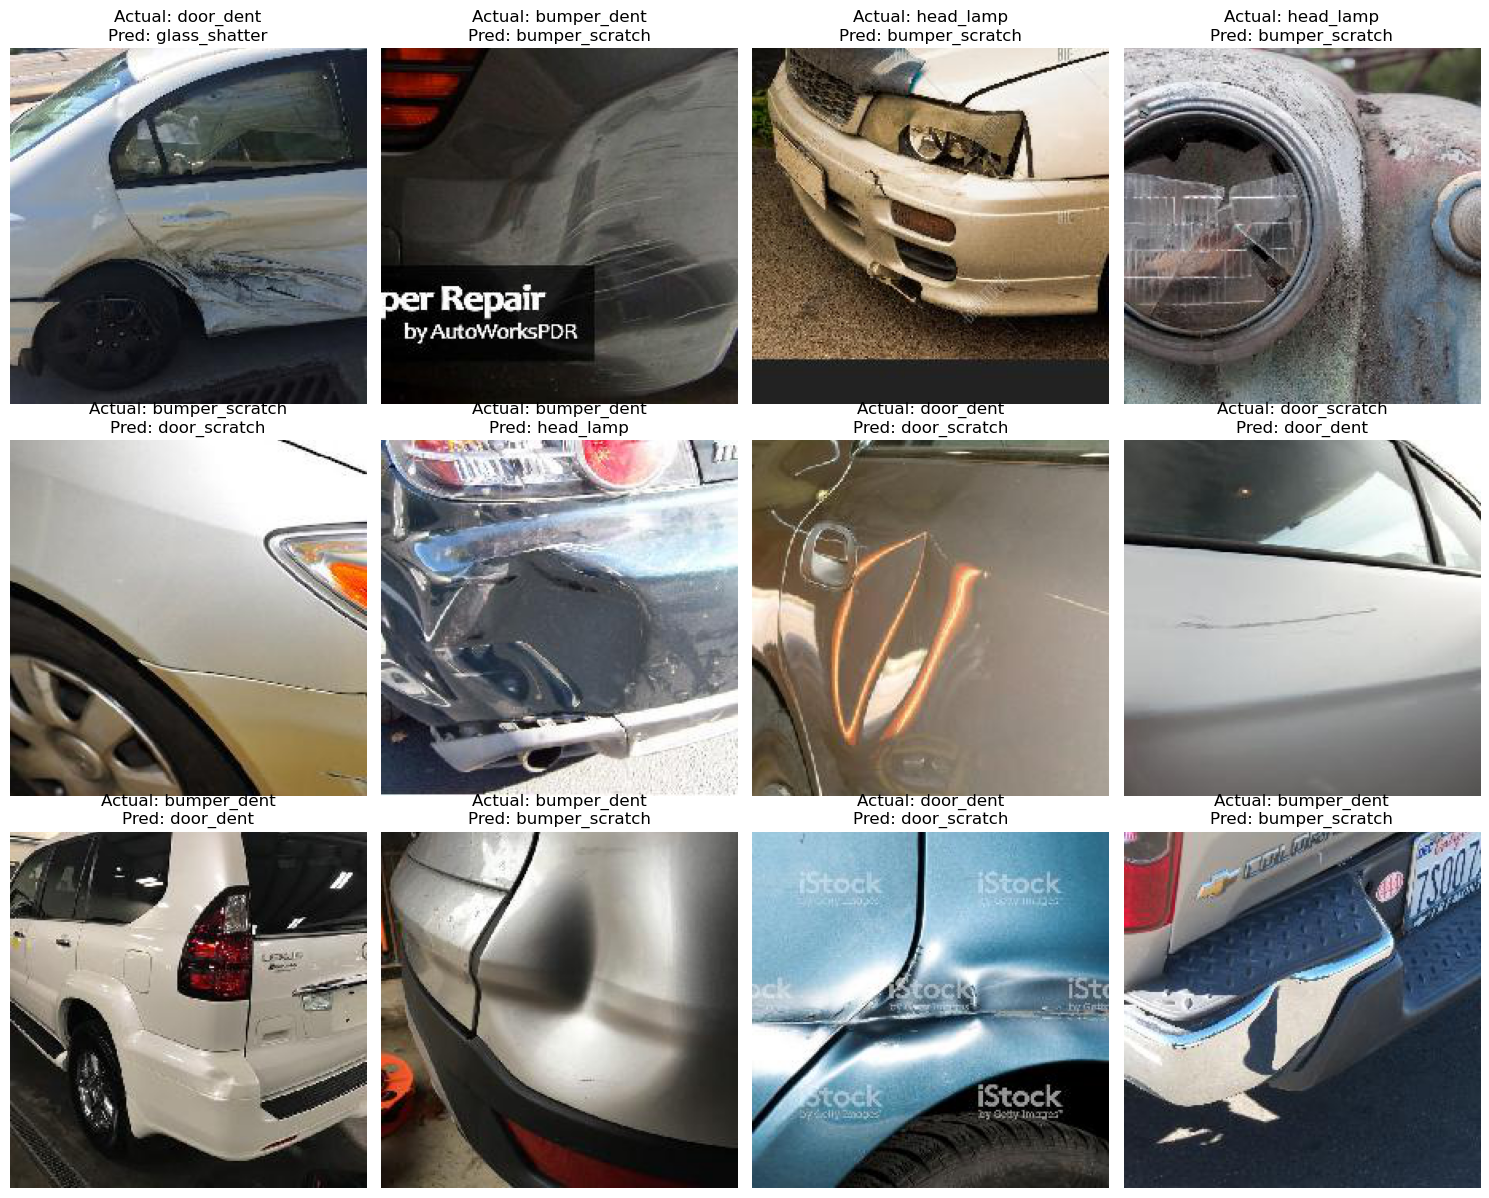

In [60]:
plt.figure(figsize=(15, 12))

num_images = min(
    12,
    len(errors)
)

for i in range(num_images):

    row = errors.iloc[i]

    image = Image.open(
        row["image_path"]
    )

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        f"Actual: {row['true_label']}\n"
        f"Pred: {row['predicted_label']}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [61]:
test_results["confidence"] = np.max(
    y_prob,
    axis=1
)

test_results.head()

,image,classes,image_path,image_hash,label,true_label,predicted_label,correct,confidence
60,image/60.jpeg,door_dent,data\image/60.jpeg,3d88c32d2da6fd3ab34b66d0e21e600aac799ef48b09a3...,2,door_dent,door_dent,True,0.459328
125,image/125.jpeg,door_scratch,data\image/125.jpeg,3a1a9a8ff5596e85bffd22165b5a641a093de12484f841...,3,door_scratch,door_scratch,True,0.480880
587,image/587.jpeg,tail_lamp,data\image/587.jpeg,028c562e26bff6e1f482bac3251e02c7a0335c75b14e42...,6,tail_lamp,tail_lamp,True,0.907480
301,image/301.jpeg,door_dent,data\image/301.jpeg,d5d554d4fdf85a57ed2121e0e5023e950a10423dfa495c...,2,door_dent,door_dent,True,0.779657
762,image/762.jpeg,door_dent,data\image/762.jpeg,7fe1ed79c252ab5dbd888396f60b4ed6b6e657f02e297c...,2,door_dent,door_dent,True,0.620982


In [62]:
uncertain = test_results.sort_values(
    "confidence"
).head(10)

uncertain[
    [
        "image_path",
        "true_label",
        "predicted_label",
        "confidence"
    ]
]

,image_path,true_label,predicted_label,confidence
284,data\image/284.jpeg,glass_shatter,bumper_scratch,0.207445
843,data\image/843.jpeg,glass_shatter,door_dent,0.213139
1086,data\image/1086.jpeg,door_dent,glass_shatter,0.294920
578,data\image/578.jpeg,bumper_dent,door_dent,0.309128
1025,data\image/1025.jpeg,bumper_scratch,door_scratch,0.321904
1327,data\image/1327.jpeg,door_dent,door_scratch,0.329655
697,data\image/697.jpeg,head_lamp,head_lamp,0.332625
1028,data\image/1028.jpeg,tail_lamp,head_lamp,0.360203
1152,data\image/1152.jpeg,bumper_scratch,bumper_scratch,0.360926
956,data\image/956.jpeg,door_scratch,bumper_scratch,0.367476


## Saving Class Names

In [63]:
class_names = list(
    label_encoder.classes_
)

with open(
    "models/class_names.txt",
    "w"
) as file:

    for class_name in class_names:
        file.write(
            class_name + "\n"
        )

print("Class names saved.")

Class names saved.


## Testing the Model on a Single Image

In [64]:
def predict_damage(image_path):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image,channels=3)

    image = tf.image.resize(image,IMG_SIZE)

    image = tf.cast(image,tf.float32)

    image = tf.expand_dims(image,axis=0)

    predictions = model.predict(image,verbose=0)[0]

    predicted_index = np.argmax(predictions)

    predicted_class = (label_encoder.inverse_transform([predicted_index])[0] )

    confidence = predictions[predicted_index]

    return predicted_class, confidence

In [65]:
sample_image = test_df.iloc[0]["image_path"]

predicted_class, confidence = predict_damage(
    sample_image
)

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence:.2%}")

Predicted class: door_dent
Confidence: 45.93%


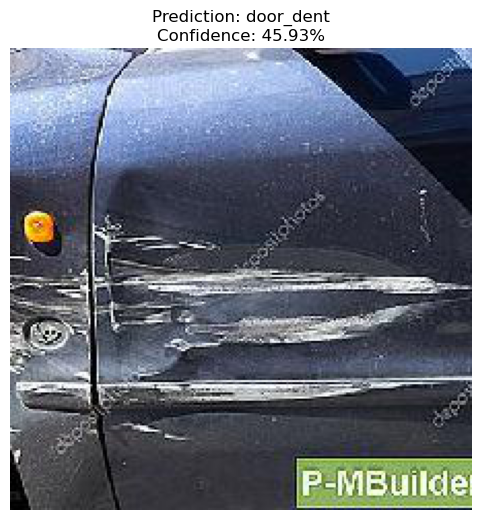

In [ ]:
image = Image.open(sample_image)

plt.figure(figsize=(7, 6))

plt.imshow(image)

plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence:.2%}"
)

plt.axis("off")

plt.show()

In [ ]:
# Top-3 Predictions

def predict_top_k(image_path,k=3):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image,channels=3)

    image = tf.image.resize(image,IMG_SIZE)

    image = tf.cast(image,tf.float32)

    image = tf.expand_dims(image,axis=0)

    predictions = model.predict(image, verbose=0)[0]

    top_indices = np.argsort(predictions)[-k:][::-1]

    results = []

    for index in top_indices:

        class_name = (
            label_encoder.inverse_transform(
                [index]
            )[0]
        )

        probability = predictions[index]

        results.append(
            (class_name,probability)
        )

    return results

In [ ]:
results = predict_top_k(
    sample_image,
    k=3
)

for class_name, probability in results:

    print(
        f"{class_name:20s} "
        f"{probability:.2%}"
    )

door_dent            45.93%
door_scratch         37.76%
bumper_scratch       11.72%


## Save Final Model

In [ ]:
model.save(
    "models/vehicle_damage_model.keras"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
import joblib

joblib.dump(
    label_encoder,
    "models/label_encoder.joblib"
)

print("Label encoder saved successfully.")

Label encoder saved successfully.


## Conclusion

The vehicle damage classification model classifies images into 7 damage categories using EfficientNetB0 transfer learning and fine-tuning. After removing duplicate images, applying class weights, and data augmentation, the model achieved 76.39% test accuracy and a 76.23% macro F1-score.

The model performed particularly well on glass-shatter damage (F1 = 0.90) and tail-lamp damage (F1 = 0.89). Most errors occurred between visually similar classes, especially door dent vs. door scratch and bumper dent vs. bumper scratch.

Overall, the model shows that transfer learning can achieve good performance on a relatively small vehicle-damage dataset and provides a useful foundation for a real-world vehicle-damage classification application.